# Differential and Derivative: Understanding Local Change, Tangent Lines, and Approximation

## 微分与导数：理解局部变化、切线斜率与近似计算

---

## Learning Objectives

After reading this chapter, you should be able to:

1. Explain the difference between **average rate of change（平均变化率）** and **instantaneous rate of change（瞬时变化率）**.  
2. Understand the derivative definition from the **difference quotient（差商）**.  
3. Interpret the derivative as the slope of a **tangent line（切线）**.  
4. Use the differential formula $dy = f'(x)\,dx$ for **local linear approximation（局部线性近似）**.  
5. Apply core derivative rules, including product rule, quotient rule, chain rule, implicit differentiation, and parametric differentiation.  
6. Use first and second derivatives to study monotonicity, extrema, convexity, and concavity.  
7. Use Python to visualize derivative concepts.  

---

## Why This Topic Matters

Many real problems are not only about values, but about **how values change**.

For example:

- In `physics`, `velocity` is the rate of change of position.  
- In `economics`, `marginal cost` is the rate of change of total cost.  
- In `machine learning`, `gradient descent` uses `derivatives` to reduce a `loss function`.  
- In `GIScience`, a `slope surface` describes how `elevation` changes over space.  
- In `risk analysis`, we may ask how much flood risk changes when rainfall increases slightly.  

Suppose we have a function:

$$
y = f(x)
$$

A simple question is:

> What is the value of $y$ when $x = 3$?

But a deeper question is:

> If $x$ changes slightly near 3, how fast does $y$ change?

This second question is the core motivation for **derivative（导数）** and **differential（微分）**.

The derivative tells us the **local rate of change**.  
The differential uses that rate to estimate the **small change in the output**.

---

## Figure Demo 1: Average Change vs Instantaneous Change

This figure shows the core motivation: a **secant line** measures average change over an interval, while a **tangent line** measures local change at one point.

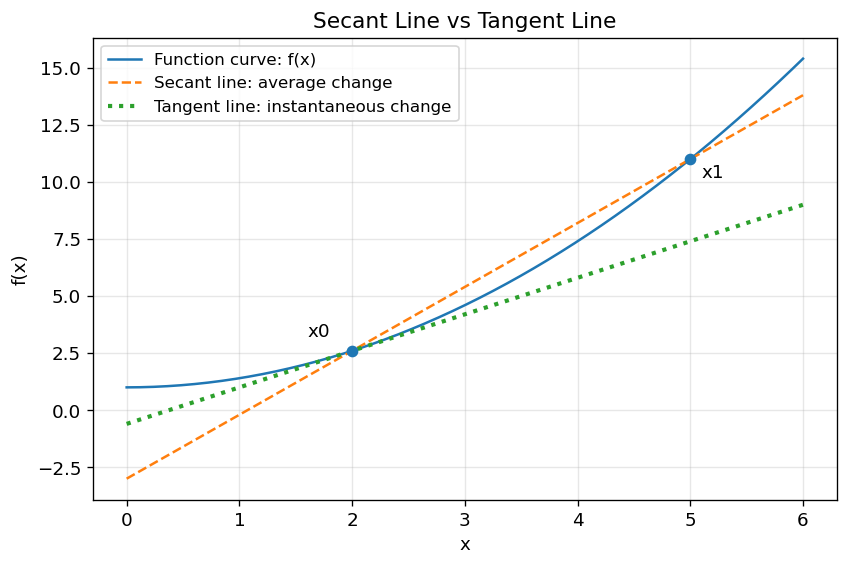

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.dpi": 120
})

def f(x):
    return 0.4 * x**2 + 1

def df(x):
    return 0.8 * x

x = np.linspace(0, 6, 300)
x0 = 2
x1 = 5

y0 = f(x0)
y1 = f(x1)

# Secant line through (x0, f(x0)) and (x1, f(x1))
secant_slope = (y1 - y0) / (x1 - x0)
secant_line = y0 + secant_slope * (x - x0)

# Tangent line at x0
tangent_slope = df(x0)
tangent_line = y0 + tangent_slope * (x - x0)

plt.figure(figsize=(8, 5))
plt.plot(x, f(x), label="Function curve: f(x)")
plt.plot(x, secant_line, "--", label="Secant line: average change")
plt.plot(x, tangent_line, ":", linewidth=2.5, label="Tangent line: instantaneous change")
plt.scatter([x0, x1], [y0, y1], zorder=5)

plt.annotate("x0", (x0, y0), xytext=(x0-0.4, y0+0.6))
plt.annotate("x1", (x1, y1), xytext=(x1+0.1, y1-0.8))

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Secant Line vs Tangent Line")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What this figure teaches:
The secant line uses two separated points and gives an average slope. The tangent line touches the curve locally and gives the derivative at a point.

## Big Picture Intuition

Imagine you are zooming in on a smooth curve.

From far away, the curve may look strongly curved.  
But if you zoom in near one point, the curve begins to look almost straight.

That local straight line is the **tangent line**.

The derivative is the slope of this tangent line.

So the derivative answers:

> Near this point, if $x$ changes a little, how much does $y$ change?

The differential goes one step further:

$$
dy = f'(x)\,dx
$$

It says:

> If $x$ changes by a tiny amount $dx$, then $y$ changes by approximately $f'(x)\,dx$.

### A useful memory:

```quote
Derivative = local slope
Differential = estimated small change
Tangent line = local linear model
```

---

## Formal Definition and Core Equations

### Difference Quotient

Suppose:

$$
y = f(x)
$$

At a point $x_0$, if $x$ changes by $\Delta x$, then the change in $y$ is:

$$
\Delta y = f(x_0 + \Delta x) - f(x_0)
$$

The average rate of change is:

$$
\frac{\Delta y}{\Delta x} = \frac{f(x_0 + \Delta x) - f(x_0)}{\Delta x}
$$

This is the slope of the secant line.

---

### Derivative

The derivative is the limit of the average rate of change as $\Delta x$ approaches 0:

$$
f'(x_0) = \lim_{\Delta x \to 0} \frac{f(x_0 + \Delta x) - f(x_0)}{\Delta x}
$$

where:

- $f'(x_0)$ is the derivative at $x_0$  
- $\Delta x$ is a small change in $x$  
- $\Delta y$ is the corresponding change in $y$  
- the limit means that the interval becomes infinitely small  

In words:

> The derivative is the instantaneous rate of change of $f(x)$ at $x_0$.

### Differential

Once we know the derivative, we define the differential:

$$
dy = f'(x)\,dx
$$

For a small but finite change $\Delta x$, we often write:

$$
\Delta y \approx dy = f'(x_0)\,\Delta x
$$

Therefore:

$$
f(x_0 + \Delta x) \approx f(x_0) + f'(x_0)\,\Delta x
$$

This is called **local linear approximation（局部线性近似）**.

---

## How It Works Step by Step

Suppose:

$$
f(x) = x^2
$$

and we want to understand how the function changes near:

$$
x_0 = 3
$$

### Step 1: Compute the function value

$$
f(3) = 9
$$

### Step 2: Compute the derivative

$$
f'(x) = 2x
$$

So:

$$
f'(3) = 6
$$

This means near $x = 3$, the function changes at about 6 units of $y$ for each 1 unit of $x$.

---

### Step 3: Use the differential

If:

$$
dx = 0.1
$$

then:

$$
dy = f'(3)\,dx = 6 \times 0.1 = 0.6
$$

Therefore:

$$
f(3.1) \approx f(3) + dy = 9 + 0.6 = 9.6
$$

The true value is:

$$
f(3.1) = 9.61
$$

So the approximation is close.

---

## Figure Demo 2: Local Linear Approximation

This demo compares the true function and its tangent-line approximation.

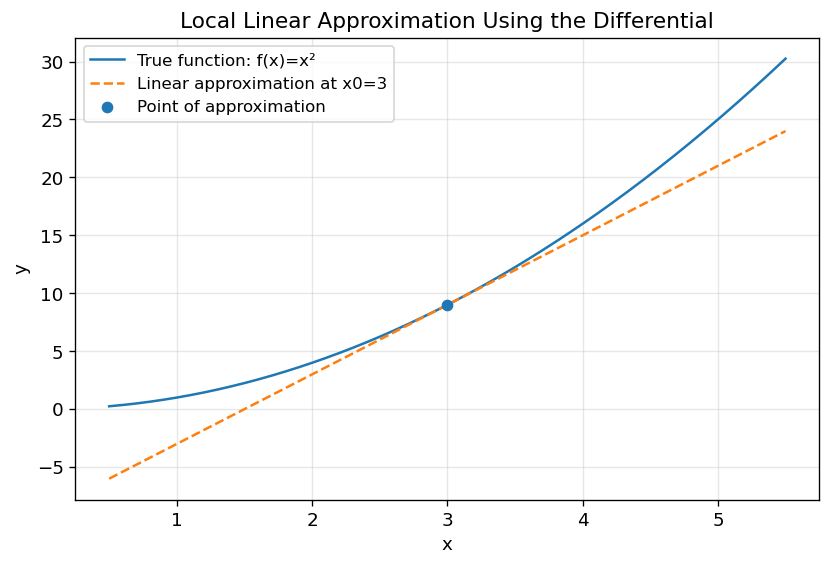

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**2

def df(x):
    return 2*x

x0 = 3
y0 = f(x0)
slope = df(x0)

def linear_approx(x):
    return y0 + slope * (x - x0)

x = np.linspace(0.5, 5.5, 300)

plt.figure(figsize=(8, 5))
plt.plot(x, f(x), label="True function: f(x)=x²")
plt.plot(x, linear_approx(x), "--", label="Linear approximation at x0=3")
plt.scatter([x0], [y0], zorder=5, label="Point of approximation")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Local Linear Approximation Using the Differential")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What this figure teaches:
- The tangent line is very accurate near $x_0=3$, but becomes less accurate as we move farther away. 

- Differential approximation is local, not global.

---

## Where Do These Derivative Rules Come From?

Before memorizing derivative rules, it is useful to see that they are not magic formulas. Most basic derivative rules come from the formal definition of derivative:

$$
f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}
$$

This definition says:

> To find the derivative, slightly perturb $x$, observe how much $f(x)$ changes, divide by the input change, and then let the input change become infinitely small.

Let us use this idea to derive the **Power Rule（幂函数求导法则）**.

---

## Deriving the Power Rule from a Simple Example

Suppose:

$$
f(x) = x^2
$$


By the derivative definition:

$$
f'(x) = \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}
$$

Substitute $f(x) = x^2$:

$$
f'(x) = \lim_{\Delta x \to 0} \frac{(x + \Delta x)^2 - x^2}{\Delta x}
$$

Expand the square:

$$
f'(x) = \lim_{\Delta x \to 0} \frac{\Delta x (2x + \Delta x)}{\Delta x}
$$

Cancel $\Delta x$:

$$
f'(x) = \lim_{\Delta x \to 0} (2x + \Delta x)
$$

Now let $\Delta x \to 0$:

$$
f'(x) = 2x
$$

So:

$$
(x^2)' = 2x
$$

--- 

## Common Derivative Rules

| Rule | Condition / Form | Derivative | Example |
|-----|----------------|------------|---------|
| **Constant Rule** | $y = C$ | $y' = 0$ | — |
| **Power Rule** | $y = x^n$ | $y' = n x^{n-1}$ | $(x^4)' = 4x^3$ |
| **Product Rule** | $y = u(x)v(x)$ | $y' = u'v + uv'$ | $y = x^2 \sin x \Rightarrow y' = 2x \sin x + x^2 \cos x$ |
| **Quotient Rule** | $y = \dfrac{u(x)}{v(x)}$ | $y' = \dfrac{u'v - uv'}{v^2}$ | — |
| **Chain Rule** | $y = f(g(x))$ | $\dfrac{dy}{dx} = \dfrac{dy}{du} \cdot \dfrac{du}{dx}$, $u=g(x)$ | $y = e^{-2x} \Rightarrow y' = -2e^{-2x}$ |

---

## Implicit Differentiation

Sometimes $y$ is not isolated as $y = f(x)$. Instead, $x$ and $y$ appear together.

### Example 1

Given:

$$
x^2 + 3y^4 + x + 2y = 1
$$

Differentiate both sides with respect to $x$:

$$
2x + 12y^3 y' + 1 + 2y' = 0
$$

Group the $y'$ terms:

$$
(12y^3 + 2)y' = -2x - 1
$$

So:

$$
y' = \frac{-2x - 1}{12y^3 + 2}
$$

### Key Rule

> Whenever you differentiate a term involving $y$, multiply by $y'$, because $y$ is itself a function of $x$.

---

### Example 2

Given:

$$
xy + \ln y = 1
$$

Differentiate:

$$
y + x y' + \frac{y'}{y} = 0
$$

Solve for $y'$:

$$
y' = \frac{-y^2}{xy + 1}
$$

---

## Parametric Differentiation

Sometimes $x$ and $y$ both depend on a third variable $t$:

$$
x = f(t), \quad y = g(t)
$$

Then:

$$
\frac{dy}{dx} = \frac{dy/dt}{dx/dt}
$$

---

### Example

$$
x = t^2, \quad y = t^3
$$

Compute derivatives:

$$
\frac{dx}{dt} = 2t, \quad \frac{dy}{dt} = 3t^2
$$

So:

$$
\frac{dy}{dx} = \frac{3t^2}{2t} = \frac{3t}{2}
$$

At $t = 1$:

$$
\frac{dy}{dx} = \frac{3}{2}
$$

---

## Higher-Order Derivatives

The first derivative tells us the slope:

$$
f'(x)
$$

The second derivative tells us how the slope changes:

$$
f''(x)
$$

### Example

$$
y = 2x^3 - 3x^2 + 5
$$

$$
y' = 6x^2 - 6x
$$

$$
y'' = 12x - 6
$$

### Interpretation

- $f'(x) > 0$: function is increasing  
- $f'(x) < 0$: function is decreasing  
- $f''(x) > 0$: curve bends upward (concave up)  
- $f''(x) < 0$: curve bends downward (concave down)  

---

## Figure Demo 4: Function, First Derivative, and Second Derivative

This figure shows how $f(x)$, $f'(x)$, and $f''(x)$ describe different aspects of the same function.

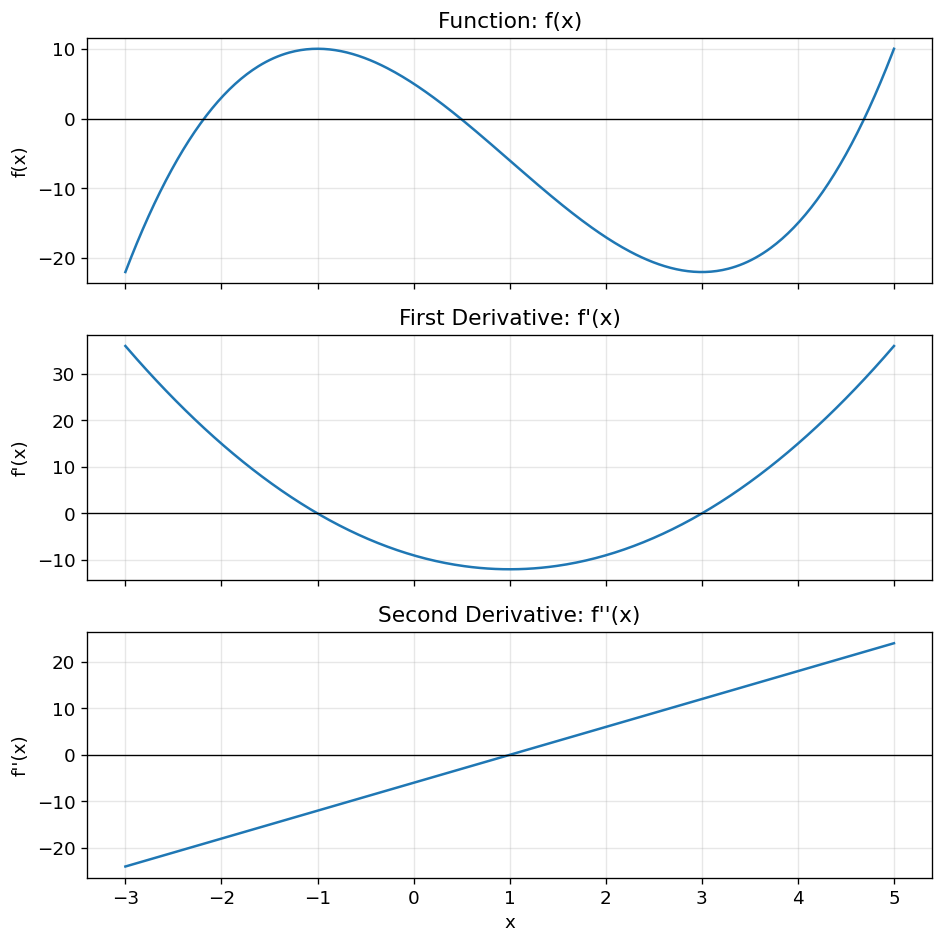

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return x**3 - 3*x**2 - 9*x + 5

def df(x):
    return 3*x**2 - 6*x - 9

def d2f(x):
    return 6*x - 6

x = np.linspace(-3, 5, 400)

fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(x, f(x))
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Function: f(x)")
axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df(x))
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("First Derivative: f'(x)")
axes[1].set_ylabel("f'(x)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(x, d2f(x))
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("Second Derivative: f''(x)")
axes[2].set_xlabel("x")
axes[2].set_ylabel("f''(x)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### What this figure teaches:
- The original function shows the curve. 
- The first derivative shows where the function increases or decreases. 
- The second derivative shows how the curve bends.

---

## Assumptions, Strengths, Weaknesses, and Trade-offs

### Assumptions

Derivative-based reasoning usually assumes that the function is:

1. **continuous（连续）** near the point of interest  
2. **differentiable（可导）** at the point of interest  
3. locally smooth enough that a tangent line is meaningful  

If a function has a sharp corner, jump, or vertical tangent, the derivative may not exist or may not behave nicely.

---

### Strengths

Derivatives are powerful because they allow us to:

- measure local change  
- approximate complicated functions locally  
- find `maxima` and `minima`  
- analyze increasing/decreasing behavior  
- study curvature  
- support optimization methods such as gradient descent  

---

### Weaknesses

Derivatives can be misleading when:

- the function is not smooth  
- the change in $x$ is too large  
- the derivative is interpreted globally rather than locally  
- symbolic differentiation becomes too complicated  
- the model function itself is wrong  

---

### Trade-off

The main trade-off is:

> **Local accuracy vs global validity**

Derivatives provide excellent **local approximations**, but they may fail to describe behavior far away from the point of interest.

## Figure Demo 5: Local Approximation Works Nearby but Fails Far Away

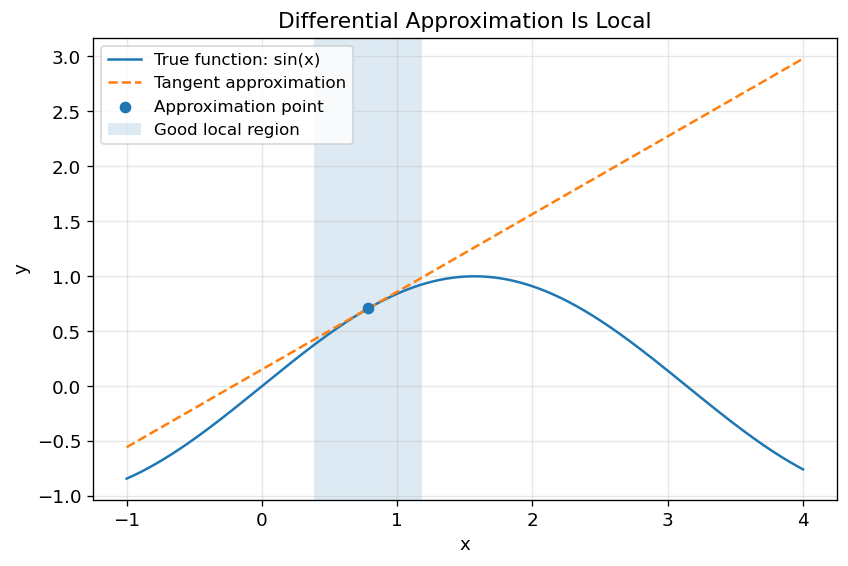

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

def df(x):
    return np.cos(x)

x0 = np.pi / 4
y0 = f(x0)
slope = df(x0)

def tangent(x):
    return y0 + slope * (x - x0)

x = np.linspace(-1, 4, 400)

plt.figure(figsize=(8, 5))
plt.plot(x, f(x), label="True function: sin(x)")
plt.plot(x, tangent(x), "--", label="Tangent approximation")
plt.scatter([x0], [y0], zorder=5, label="Approximation point")

plt.axvspan(x0 - 0.4, x0 + 0.4, alpha=0.15, label="Good local region")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Differential Approximation Is Local")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### What this figure teaches:

- The tangent line approximates the curve well near the chosen point, but the error grows farther away.

---

## Worked Toy Example

Estimate:

$$
\sqrt{4.1}
$$

using differential approximation.

### Step 1: Choose the function

$$
f(x) = \sqrt{x}
$$

### Step 2: Choose a nearby easy point

Use:

$$
x_0 = 4
$$

because:

$$
\sqrt{4} = 2
$$

### Step 3: Compute the derivative

$$
f'(x) = \frac{1}{2\sqrt{x}}
$$

At $x_0 = 4$:

$$
f'(4) = \frac{1}{2 \cdot 2} = \frac{1}{4}
$$

### Step 4: Compute the small change

$$
\Delta x = 4.1 - 4 = 0.1
$$

### Step 5: Apply differential approximation

$$
f(4.1) \approx f(4) + f'(4)\Delta x
$$

$$
\sqrt{4.1} \approx 2 + \frac{1}{4}(0.1) = 2.025
$$


The true value is about:

$$
2.0248
$$

So the approximation is very accurate.

---

## Figure Demo 6: Worked Example Visualization

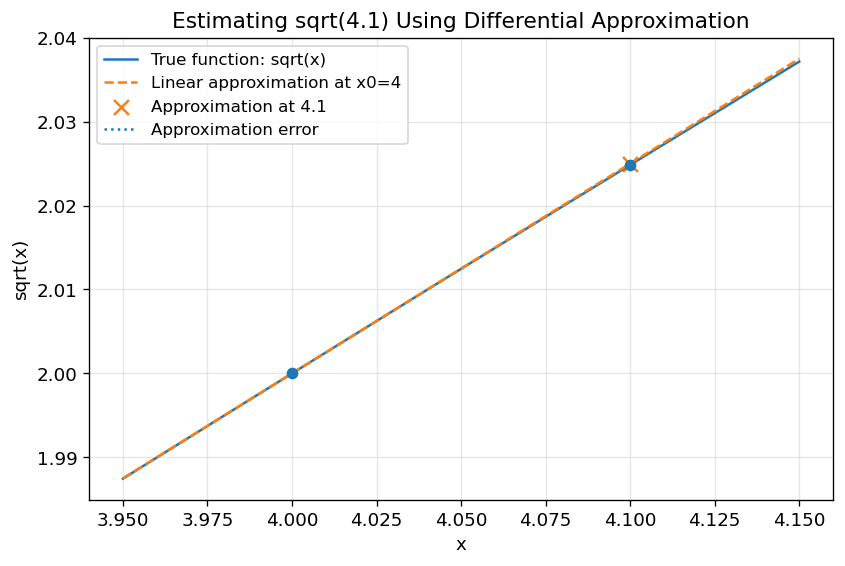

Approximation: 2.025
True value: 2.0248456731316584
Absolute error: 0.00015432686834149223


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sqrt(x)

def df(x):
    return 1 / (2 * np.sqrt(x))

x0 = 4
x_target = 4.1
y0 = f(x0)
approx_target = y0 + df(x0) * (x_target - x0)
true_target = f(x_target)

x = np.linspace(3.95, 4.15, 300)
tangent = y0 + df(x0) * (x - x0)

plt.figure(figsize=(8, 5))
plt.plot(x, f(x), label="True function: sqrt(x)")
plt.plot(x, tangent, "--", label="Linear approximation at x0=4")

plt.scatter([x0, x_target], [y0, true_target], zorder=5)
plt.scatter([x_target], [approx_target], marker="x", s=80, label="Approximation at 4.1")

plt.vlines(x_target, approx_target, true_target, linestyles=":", label="Approximation error")

plt.xlabel("x")
plt.ylabel("sqrt(x)")
plt.title("Estimating sqrt(4.1) Using Differential Approximation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Approximation:", approx_target)
print("True value:", true_target)
print("Absolute error:", abs(true_target - approx_target))

---

## Python Lab: Derivatives, Tangent Lines, and Approximation Error

In this lab, we will:

1. define a function  
2. compute its derivative  
3. plot the tangent line  
4. compare approximation error for different $\Delta x$ values  

We use:

$$
f(x) = \sin x
$$

and:

$$
f'(x) = \cos x
$$

---

### Lab Code

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)

def df(x):
    return np.cos(x)

x0 = np.pi / 6
f_x0 = f(x0)
slope_x0 = df(x0)

# Try several changes in x
delta_values = np.array([0.01, 0.05, 0.1, 0.3, 0.6, 1.0])

rows = []

for dx in delta_values:
    true_value = f(x0 + dx)
    approx_value = f_x0 + slope_x0 * dx
    error = abs(true_value - approx_value)
    
    rows.append({
        "dx": dx,
        "true f(x0+dx)": true_value,
        "linear approximation": approx_value,
        "absolute error": error
    })

results = pd.DataFrame(rows)
print(results)

     dx  true f(x0+dx)  linear approximation  absolute error
0  0.01       0.508635              0.508660        0.000025
1  0.05       0.542658              0.543301        0.000643
2  0.10       0.583960              0.586603        0.002642
3  0.30       0.733596              0.759808        0.026211
4  0.60       0.901663              1.019615        0.117953
5  1.00       0.998886              1.366025        0.367139


### Plot the Error

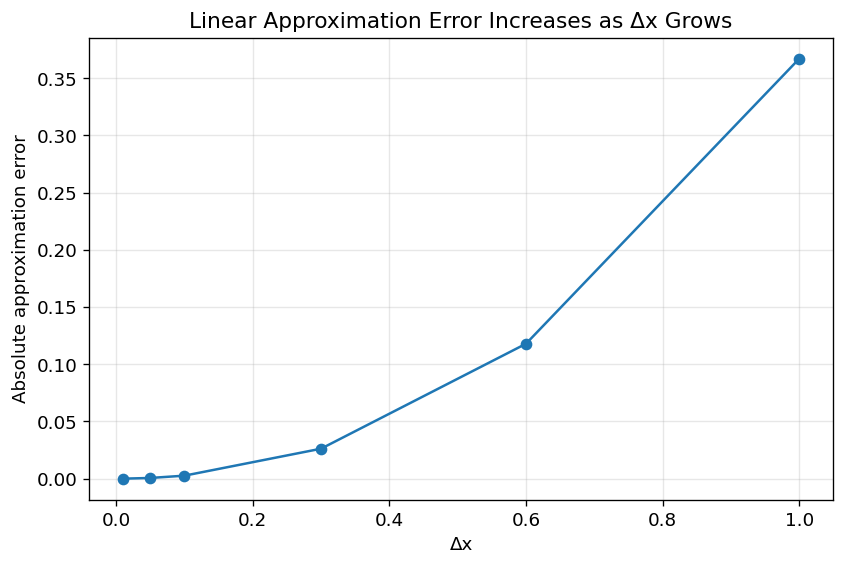

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(results["dx"], results["absolute error"], marker="o")

plt.xlabel("Δx")
plt.ylabel("Absolute approximation error")
plt.title("Linear Approximation Error Increases as Δx Grows")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation

The error is small when $\Delta x$ is small.

As $\Delta x$ increases, the tangent line becomes less reliable.

This is the practical meaning of:

$$
\Delta y \approx dy
$$

It is a **local approximation**, not an exact global rule.

---

## How to Interpret the Results

### Interpreting $f'(x)$

If:

$$
f'(x) > 0
$$

then the function is increasing at that point.

If:

$$
f'(x) < 0
$$

then the function is decreasing at that point.

If:

$$
f'(x) = 0
$$

then the function has a horizontal tangent. It may be a local maximum, local minimum, or neither.

---

### Interpreting $f''(x)$

If:

$$
f''(x) > 0
$$

then the function bends upward (concave up).

If:

$$
f''(x) < 0
$$

then the function bends downward (concave down).

If $f''(x)$ changes sign, the point may be an **inflection point（拐点）**.

---

### Interpreting Differential Approximation

The formula:

$$
f(x_0 + \Delta x) \approx f(x_0) + f'(x_0)\,\Delta x
$$

means:

> Use the tangent line at $x_0$ to estimate the function near $x_0$.

The most common mistake is to forget the phrase **"near $x_0$"**.

---

## Common Pitfalls and Misunderstandings

### Pitfall 1: Confusing $\Delta y$ and $dy$

$\Delta y$ is the true change:

$$
\Delta y = f(x_0 + \Delta x) - f(x_0)
$$

$dy$ is the linear approximation:

$$
dy = f'(x_0)\,\Delta x
$$

They are close only when $\Delta x$ is small.

---

### Pitfall 2: Forgetting the chain rule

For:

$$
y = \sin(x^2)
$$

the derivative is **not**:

$$
\cos(x^2)
$$

The correct answer is:

$$
2x \cos(x^2)
$$

because the inside function $x^2$ also changes.

---

### Pitfall 3: Forgetting $y'$ in implicit differentiation

For:

$$
\frac{d}{dx}(y^4)
$$

the correct derivative is:

$$
4y^3 y'
$$

not:

$$
4y^3
$$

because $y$ is a function of $x$.

---

### Pitfall 4: Treating local slope as global behavior

If:

$$
f'(2) = 5
$$

this only tells us the local rate of change near $x = 2$.

It does **not** mean the function always has slope 5.

---

### Pitfall 5: Misreading convex and concave

A useful memory:


- f''(x) > 0  → slope increasing  → curve bends upward
- f''(x) < 0  → slope decreasing  → curve bends downward

---

## Comparison with Related Concepts

| Concept | Main Question | Formula / Tool | Interpretation |
|--------|--------------|----------------|----------------|
| Difference | How much did the value change? | $\Delta y = f(b) - f(a)$ | Actual change |
| Average rate of change | How fast did it change over an interval? | $\dfrac{f(b)-f(a)}{b-a}$ | Secant slope |
| Derivative | How fast is it changing at one point? | $f'(x)$ | Tangent slope |
| Differential | What is the approximate small change? | $dy = f'(x)\,dx$ | Local linear change |
| Second derivative | How is the slope changing? | $f''(x)$ | Curvature |

---

## Practical Advice

Use derivatives when you want to:

- analyze local sensitivity  
- find maximum or minimum values  
- understand increasing and decreasing intervals  
- build local approximations  
- solve optimization problems  
- understand gradients in machine learning  

A practical workflow:

1. Identify the function.
2. Decide which derivative rule applies.
3. Compute the first derivative.
4. Interpret the sign of the first derivative.
5. Solve f'(x)=0 if looking for extrema.
6. Compute the second derivative if curvature matters.
7. Use differential approximation only for small changes.

When using figures, inspect:

- where the tangent line touches the curve  
- where $f'(x) = 0$  
- where $f''(x) = 0$  
- where the approximation error becomes large  

---

## Summary

A derivative measures the instantaneous rate of change of a function.

A differential estimates a small change in the output using:

$$
dy = f'(x)\,dx
$$

The core intuition is:

> Near a point, a smooth curve behaves almost like a straight line.

Derivatives help us study slope, change, approximation, extrema, monotonicity, and curvature.

The main limitation is that derivative-based approximation is **local**. It works best near the point where the tangent line is constructed.

---

## Quiz

### Conceptual Questions

---

**Q1: What does the derivative $f'(x_0)$ represent geometrically?**  
A. The area under the curve  
B. The slope of the tangent line at $x_0$  
C. The average value of the function  
D. The maximum value of the function  

<details>
<summary>Answer</summary>

**Correct answer: B.**

The derivative represents the slope of the tangent line at a specific point.

</details>

---

**Q2: What is the main difference between a secant line and a tangent line?**  
A. A secant line measures local change; a tangent line measures average change  
B. A secant line uses two points; a tangent line describes local behavior at one point  
C. A tangent line always crosses the x-axis  
D. A secant line only applies to linear functions  

<details>
<summary>Answer</summary>

**Correct answer: B.**

A secant line connects two points and gives average change. A tangent line describes local change at one point.

</details>

---

**Q3: Why do we need the chain rule?**  
A. To differentiate constants  
B. To differentiate products only  
C. To differentiate composite functions  
D. To find the area under a curve  

<details>
<summary>Answer</summary>

**Correct answer: C.**

The chain rule is used when one function is inside another function, such as $f(g(x))$.

</details>

---

**Q4: In implicit differentiation, why does $\frac{d}{dx}(y^3) = 3y^2 y'$?**  
A. Because $y$ is treated as a constant  
B. Because $y$ is a function of $x$  
C. Because $y^3$ has no derivative  
D. Because all implicit derivatives equal zero  

<details>
<summary>Answer</summary>

**Correct answer: B.**

Since $y$ depends on $x$, we must apply the chain rule and multiply by $y'$.

</details>

---

**Q5: What does $f''(x) > 0$ usually indicate?**  
A. The function is decreasing  
B. The function is convex or bending upward  
C. The function has no derivative  
D. The function is constant  

<details>
<summary>Answer</summary>

**Correct answer: B.**

A positive second derivative means the slope is increasing, so the curve bends upward.

</details>

---

### Applied Questions

**Q6: Use differential approximation to estimate $\sqrt{9.2}$.**  
A. 3.0033  
B. 3.0333  
C. 3.3000  
D. 2.9333  

<details>
<summary>Answer</summary>

**Correct answer: B.**

Let:

$$
f(x) = \sqrt{x}
$$

Choose:

$$
x_0 = 9
$$

Then:

$$
f(9) = 3, \quad f'(x) = \frac{1}{2\sqrt{x}}, \quad f'(9) = \frac{1}{6}
$$

$$
\Delta x = 9.2 - 9 = 0.2
$$

So:

$$
\sqrt{9.2} \approx 3 + \frac{1}{6}(0.2) = 3.0333
$$

</details>

---

**Q7: Find $y'$ for $xy + \ln y = 1$.**  
A. $\dfrac{y^2}{xy + 1}$  
B. $-\dfrac{y^2}{xy + 1}$  
C. $\dfrac{x^2}{xy + 1}$  
D. $\dfrac{x}{y}$  

<details>
<summary>Answer</summary>

**Correct answer: B.**

Differentiate both sides:

$$
y + x y' + \frac{y'}{y} = 0
$$

Group $y'$:

$$
x y' + \frac{y'}{y} = -y
$$

$$
y'\left(x + \frac{1}{y}\right) = -y
$$

So:

$$
y' = \frac{-y^2}{xy + 1}
$$

</details>

---

### Explain in Your Own Words

**Q8: Explain why differential approximation works well only near the chosen point $x_0$.**

<details>
<summary>Answer</summary>

Differential approximation uses the tangent line at $x_0$. Near $x_0$, a smooth curve looks almost straight, so the tangent line is a good approximation. Far away from $x_0$, the curve may bend away from the tangent line, so the approximation error becomes larger.

</details>

## Common Derivatives

### Trigonometric
$$
(\sin x)' = \cos x
$$
$$
(\cos x)' = -\sin x
$$
$$
(\tan x)' = \sec^2 x
$$

### Exponential & Log
$$
(e^x)' = e^x
$$
$$
(\ln x)' = \frac{1}{x}
$$
